# Local Inference — UNet Water Body Experiments

Runs inference from one or more trained experiment checkpoints on a local
PlanetScope scene. Outputs georeferenced GeoTIFF predictions alongside a
visual comparison across experiments.

**Expected directory layout:**
```
experiments/
  baseline_indices_only/
      best_model.pt
      norm_stats.npy
  optionB_bands_only/
      best_model.pt
      norm_stats.npy
  optionB_bands_and_indices/
      best_model.pt
      norm_stats.npy
```

**Memory note:** inference is run one chip at a time so RAM usage is
proportional to `CHIP_SIZE`, not the full scene size.

---
## 0. Configuration
Edit this cell only.

In [1]:
from pathlib import Path

# ── Input ─────────────────────────────────────────────────────────────────────
# Path to the local 10-band PlanetScope GeoTIFF to run inference on
INPUT_IMAGE   = Path(r"M:\data\unet-test\ps\20240118_150740_48_24c9_3B_AnalyticMS_SR_8b_bandmath.tif")

# Root of the copied experiments folder
EXPERIMENTS_DIR = Path(r"./experiments")

# Output directory for predictions (created if it doesn't exist)
OUTPUT_DIR    = INPUT_IMAGE.parent / "predictions"

# ── Experiments to run ────────────────────────────────────────────────────────
# Each entry: (experiment_name, spectral_bands, display_label)
# spectral_bands must match what the model was trained on
EXPERIMENTS = [
    ("baseline_indices_only",      [6, 7, 8, 9],       "1: Indices only"),
    ("optionB_bands_only",         [0, 1, 2, 3, 4, 5], "2: Bands only"),
    ("optionB_bands_and_indices",  list(range(10)),     "3: Bands + Indices"),
]

# ── Model architecture (must match training config) ───────────────────────────
ENCODER_CHANNELS = [16, 32, 64, 128]
CHIP_SIZE        = 256

# ── Output ────────────────────────────────────────────────────────────────────
SAVE_GEOTIFF  = True    # save georeferenced prediction GeoTIFFs
SAVE_PLOT     = True    # save comparison figure as PNG

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Input : {INPUT_IMAGE}")
print(f"Output: {OUTPUT_DIR}")

Input : M:\data\unet-test\ps\20240118_150740_48_24c9_3B_AnalyticMS_SR_8b_bandmath.tif
Output: M:\data\unet-test\ps\predictions


---
## 1. Imports

In [2]:
import time, os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

import rasterio
from rasterio.windows import Window

import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.13.0+cpu


In [3]:
def print_time(start, end, process = ""):
    """
        prints message with elapsed time of process
    """
    elapsed = end - start
    time_str = time.strftime("%H hr %M min %S sec", time.gmtime(elapsed))
    print(f"[{os.getpid()}]\t{process} completed in {time_str}", flush=True)
    return

---
## 2. Model Definition
Must match the architecture used during training.

In [11]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels, out_channels=2, encoder_chn=None):
        super().__init__()
        if encoder_chn is None:
            encoder_chn = [16, 32, 64, 128]
        self.encoders = nn.ModuleList()
        self.pools    = nn.ModuleList()
        prev = in_channels
        for ch in encoder_chn:
            self.encoders.append(DoubleConv(prev, ch))
            self.pools.append(nn.MaxPool2d(2))
            prev = ch
        self.bottleneck = DoubleConv(prev, prev * 2)
        prev = prev * 2
        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        for ch in reversed(encoder_chn):
            self.upconvs.append(nn.ConvTranspose2d(prev, ch, 2, stride=2))
            self.decoders.append(DoubleConv(ch * 2, ch))
            prev = ch
        self.output_conv = nn.Conv2d(prev, out_channels, 1)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x); skips.append(x); x = pool(x)
        x = self.bottleneck(x)
        for up, dec, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = up(x)
            if x.shape != skip.shape:
                x = F.pad(x, [0, skip.shape[3]-x.shape[3], 0, skip.shape[2]-x.shape[2]])
            x = dec(torch.cat([skip, x], dim=1))
        return self.output_conv(x)


print("UNet defined.")

UNet defined.


---
## 3. Inference Utilities

In [17]:
def get_chip_offsets(total: int, chip_size: int):
    """Offsets covering full extent including partial final chip."""
    offsets = list(range(0, total - chip_size + 1, chip_size))
    if not offsets or offsets[-1] + chip_size < total:
        offsets.append(total - chip_size)
    return offsets


def load_chip(src, row: int, col: int, chip_size: int, band_indices: list):
    """Read a chip from an open rasterio dataset."""
    window = Window(col, row, chip_size, chip_size)
    data   = src.read([b + 1 for b in band_indices], window=window)
    return data.astype(np.float32)


def predict_scene(img_path: Path, model: nn.Module,
                  spectral_bands: list, mean: np.ndarray, std: np.ndarray,
                  chip_size: int = 256, device=torch.device("cpu"),
                  verbose: bool = True) -> tuple:
    """
    Returns:
        pred     : uint8 array  — 0=not-water, 1=water, 255=no-data
        prob_map : float32 array — water probability 0–1, nan where no-data
    """
    model.eval()

    with rasterio.open(img_path) as src:
        H, W = src.height, src.width
        ndwi = src.read(8, masked=False).astype(np.float32)
    nodata_mask = np.isnan(ndwi)

    prob_map  = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.uint8)

    row_offsets = get_chip_offsets(H, chip_size)
    col_offsets = get_chip_offsets(W, chip_size)
    total_chips = len(row_offsets) * len(col_offsets)
    chip_n      = 0

    with rasterio.open(img_path) as src:
        for r in row_offsets:
            for c in col_offsets:
                chip_n += 1
                if verbose and chip_n % 20 == 0:
                    print(f"    chip {chip_n}/{total_chips}", end="\r")
                window = Window(c, r, chip_size, chip_size)
                chip   = src.read([b + 1 for b in spectral_bands],
                                  window=window).astype(np.float32)
                chip   = (chip - mean[:, None, None]) / std[:, None, None]
                chip   = np.nan_to_num(chip, nan=0.0, posinf=1.0, neginf=-1.0)
                tensor = torch.from_numpy(chip).unsqueeze(0).to(device)
                with torch.no_grad():
                    prob = torch.softmax(model(tensor), dim=1)[0, 1].cpu().numpy()
                prob_map[r:r+chip_size,  c:c+chip_size] += prob
                count_map[r:r+chip_size, c:c+chip_size] += 1

    if verbose:
        print(f"    {total_chips}/{total_chips} chips done")

    # Average overlapping chips
    avg_prob = prob_map / np.maximum(count_map, 1)

    # Binary prediction
    pred = (avg_prob > 0.5).astype(np.uint8)
    pred[nodata_mask] = 255

    # Probability map: set no-data to nan, scale to uint16 range
    avg_prob[nodata_mask] = np.nan

    return pred, avg_prob


def save_geotiff(pred: np.ndarray, reference_path: Path, output_path: Path):
    """Write prediction as a georeferenced GeoTIFF matching the input scene."""
    with rasterio.open(reference_path) as src:
        profile = src.profile.copy()
    profile.update(count=1, dtype="uint8", compress="lzw", nodata=255)
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(pred[np.newaxis, ...])
    print(f"  Saved: {output_path.name}")


def save_prob_geotiff(prob_uint16: np.ndarray, reference_path: Path, output_path: Path):
    """
    Save a pre-scaled uint16 probability raster.
    Values: 0–1000 (divide by 1000 to recover probability), 65535=no-data.
    """
    with rasterio.open(reference_path) as src:
        profile = src.profile.copy()
    profile.update(count=1, dtype="uint16", compress="lzw", nodata=65535)
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(prob_uint16[np.newaxis, ...])
    print(f"  Saved prob:    {output_path}")


print("Inference utilities defined.")

Inference utilities defined.


In [13]:
def compute_local_stats(img_path: Path, spectral_bands: list,
                        n_chips: int = 200, chip_size: int = 256) -> tuple:
    """
    Estimate per-channel mean and std from random chips of the local scene.
    Uses nanmean/nanstd so NaN no-data values in index bands are ignored.
    """
    with rasterio.open(img_path) as src:
        H, W = src.height, src.width

    row_offsets = get_chip_offsets(H, chip_size)
    col_offsets = get_chip_offsets(W, chip_size)
    all_offsets = [(r, c) for r in row_offsets for c in col_offsets]

    sample = all_offsets if len(all_offsets) <= n_chips else \
             [all_offsets[i] for i in np.random.choice(
                 len(all_offsets), n_chips, replace=False)]

    all_data = []
    with rasterio.open(img_path) as src:
        for r, c in sample:
            window = Window(c, r, chip_size, chip_size)
            chip   = src.read([b + 1 for b in spectral_bands],
                              window=window, masked=False).astype(np.float32)
            all_data.append(chip.reshape(len(spectral_bands), -1))

    all_data = np.concatenate(all_data, axis=1)
    mean     = np.nanmean(all_data, axis=1)
    std      = np.nanstd(all_data,  axis=1) + 1e-6
    return mean, std


def load_norm_stats(stats_path: Path, img_path: Path,
                    spectral_bands: list, chip_size: int = 256) -> tuple:
    """
    Load normalisation stats, preferring local stats in this order:
      1. "local" key in saved stats dict   — per-source stats from training
      2. Computed on the fly from img_path — default for local inference
      3. "global" or "mukherjee" key       — last resort with warning
    """
    stats = np.load(stats_path, allow_pickle=True).item()

    if "local" in stats:
        print("  Stats: loaded 'local' from norm_stats.npy")
        return stats["local"]

    # Compute from the local scene directly — preferred for local inference
    print("  Stats: computing from local scene (no 'local' key in norm_stats.npy)...")
    mean, std = compute_local_stats(img_path, spectral_bands, chip_size=chip_size)
    print(f"    mean: {np.round(mean, 3)}")
    print(f"    std:  {np.round(std,  3)}")
    return mean, std

---
## 4. Load Image Metadata & False Color Preview

In [14]:
import geopandas as gpd
from rasterio.warp import transform_bounds
from rasterio.transform import rowcol

# ── Shapefile bbox config ─────────────────────────────────────────────────────
BBOX_SHAPEFILE = Path(r"m:\data\unet-test\sample_pond_bboxes-32119\LCP_bbox-32119.shp")

# ── Read bbox CRS from shapefile (do NOT reproject the vector) ────────────────
bbox_gdf  = gpd.read_file(BBOX_SHAPEFILE)
bbox_crs  = bbox_gdf.crs
bounds    = bbox_gdf.total_bounds   # (minx, miny, maxx, maxy) in vector CRS
print(f"Vector CRS : {bbox_crs}")
print(f"Bbox       : {bounds}")

# ── Reproject bbox bounds into raster CRS for windowed reading ────────────────
with rasterio.open(INPUT_IMAGE) as src:
    img_crs      = src.crs
    transform    = src.transform
    img_h, img_w = src.height, src.width
    print(f"\nFile  : {INPUT_IMAGE.name}")
    print(f"Shape : {img_h} × {img_w} px  ({src.count} bands)")
    print(f"CRS   : {img_crs}")
    print(f"Res   : {src.res}")
    print(f"dtype : {src.dtypes[0]}")

    # Transform bbox bounds from vector CRS → raster CRS
    bounds_img_crs = transform_bounds(bbox_crs, img_crs,
                                      bounds[0], bounds[1],
                                      bounds[2], bounds[3])
    print(f"\nBbox (raster CRS): {bounds_img_crs}")

    # Convert to pixel row/col
    row_min, col_min = rowcol(transform, bounds_img_crs[0], bounds_img_crs[3])
    row_max, col_max = rowcol(transform, bounds_img_crs[2], bounds_img_crs[1])

    # Clamp to image extent
    row_min = max(0, int(row_min))
    col_min = max(0, int(col_min))
    row_max = min(img_h, int(row_max))
    col_max = min(img_w, int(col_max))

    print(f"Pixel window : rows {row_min}:{row_max}, cols {col_min}:{col_max}")
    print(f"Preview size : {row_max - row_min} × {col_max - col_min} px")

    # Read only the bbox chip
    window  = Window(col_min, row_min, col_max - col_min, row_max - row_min)
    preview = src.read([6, 4, 3], window=window, masked=False).astype(np.float32)


Vector CRS : EPSG:32119
Bbox       : [734874.72731276 169237.23166161 742874.72731276 177237.23166161]

File  : 20240118_150740_48_24c9_3B_AnalyticMS_SR_8b_bandmath.tif
Shape : 9299 × 12693 px  (10 bands)
CRS   : EPSG:32618
Res   : (3.0, 3.0)
dtype : float32

Bbox (raster CRS): (261402.13513150212, 3905572.5494858054, 269721.607725486, 3913892.005807749)
Pixel window : rows 3050:5823, cols 2199:4972
Preview size : 2773 × 2773 px


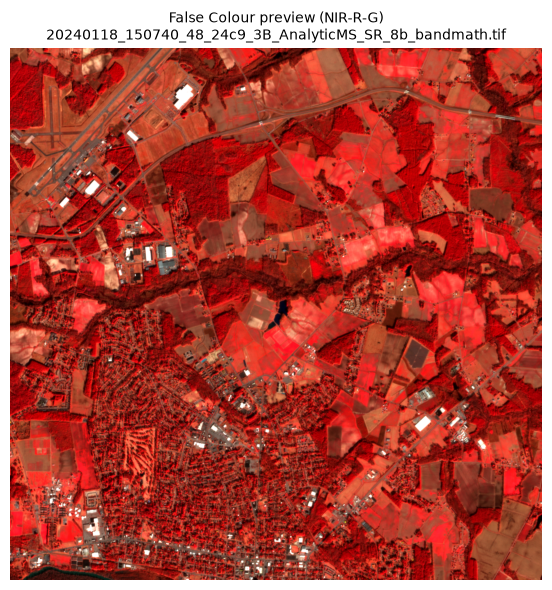

In [15]:
# False colour stretch
fc_preview = preview.transpose(1, 2, 0)
p2, p98    = np.nanpercentile(fc_preview, (2, 98))
fc_preview = np.clip((fc_preview - p2) / (p98 - p2 + 1e-6), 0, 1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(fc_preview)
ax.set_title(f"False Colour preview (NIR-R-G)\n{INPUT_IMAGE.name}", fontsize=10)
ax.axis("off")
plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "false_colour_preview.png", dpi=150, bbox_inches="tight")
# plt.close()
# print(f"Preview saved: {OUTPUT_DIR / 'false_colour_preview.png'}")

---
## 5. Run Inference

In [18]:
predictions = []   # list of (display_label, pred_array)

for exp_name, spectral_bands, display_label in EXPERIMENTS:
    start_exp = time.time()

    ckpt_dir   = EXPERIMENTS_DIR / exp_name
    model_path = ckpt_dir / "best_model.pt"
    stats_path = ckpt_dir / "norm_stats.npy"

    print(f"\n── {display_label} ──────────────────────")

    # Validate files exist
    if not model_path.exists():
        print(f"  Skipping — best_model.pt not found at {model_path}")
        continue
    if not stats_path.exists():
        print(f"  Skipping — norm_stats.npy not found at {stats_path}")
        continue

    # Load normalisation stats
    mean, std = load_norm_stats(stats_path, INPUT_IMAGE, spectral_bands,
                                chip_size=CHIP_SIZE)
    print(f"  Bands : {spectral_bands}")
    print(f"  mean  : {np.round(mean, 3)}")
    print(f"  std   : {np.round(std,  3)}")

    # Load model
    model = UNet(in_channels=len(spectral_bands),
                 encoder_chn=ENCODER_CHANNELS).to(DEVICE)
    model.load_state_dict(
        torch.load(model_path, map_location=DEVICE, weights_only=True)
    )
    print(f"  Loaded: {model_path.name}")

    # Run inference
    pred, prob_map = predict_scene(
        INPUT_IMAGE, model, spectral_bands, mean, std,
        chip_size=CHIP_SIZE, device=DEVICE
    )
    predictions.append((display_label, exp_name, prob_map))

    water_pct = (pred == 1).sum() / max((pred != 255).sum(), 1) * 100
    print(f"  Water: {water_pct:.2f}% of valid pixels using 50% pred threshold")

    if SAVE_GEOTIFF:
        # out_name = f"{INPUT_IMAGE.stem}_{exp_name}_pred.tif"
        # save_geotiff(pred, INPUT_IMAGE, OUTPUT_DIR / out_name)

        # Save probability raster — scale to 0–1000 uint16, nan→65535
        prob_scaled         = (prob_map * 1000).astype(np.float32)
        prob_uint16         = np.where(np.isnan(prob_map), 65535,
                                    prob_scaled).astype(np.uint16)
        prob_name = f"{INPUT_IMAGE.stem}_{exp_name}_prob.tif"
        save_prob_geotiff(prob_uint16, INPUT_IMAGE, OUTPUT_DIR / prob_name)
    
    end_exp = time.time()
    print_time(start_exp, end_exp, display_label)

print(f"\nInference complete — {len(predictions)} experiment(s) run.")


── 1: Indices only ──────────────────────
  Stats: computing from local scene (no 'local' key in norm_stats.npy)...
    mean: [ 0.358 -0.396  0.237 -0.119]
    std:  [0.294 0.3   0.2   0.223]
  Bands : [6, 7, 8, 9]
  mean  : [ 0.358 -0.396  0.237 -0.119]
  std   : [0.294 0.3   0.2   0.223]
  Loaded: best_model.pt
    1850/1850 chips done
  Water: 73.47% of valid pixels using 50% pred threshold
  Saved prob:    M:\data\unet-test\ps\predictions\20240118_150740_48_24c9_3B_AnalyticMS_SR_8b_bandmath_baseline_indices_only_prob.tif
[24692]	1: Indices only completed in 00 hr 03 min 02 sec

── 2: Bands only ──────────────────────
  Stats: computing from local scene (no 'local' key in norm_stats.npy)...
    mean: [ 200.808  214.56   342.086  415.378  629.62  1269.956]
    std:  [ 227.989  258.699  356.035  454.137  596.242 1091.807]
  Bands : [0, 1, 2, 3, 4, 5]
  mean  : [ 200.808  214.56   342.086  415.378  629.62  1269.956]
  std   : [ 227.989  258.699  356.035  454.137  596.242 1091.807]
  L

---
## 6. Visual Comparison

NameError: name 'fc' is not defined

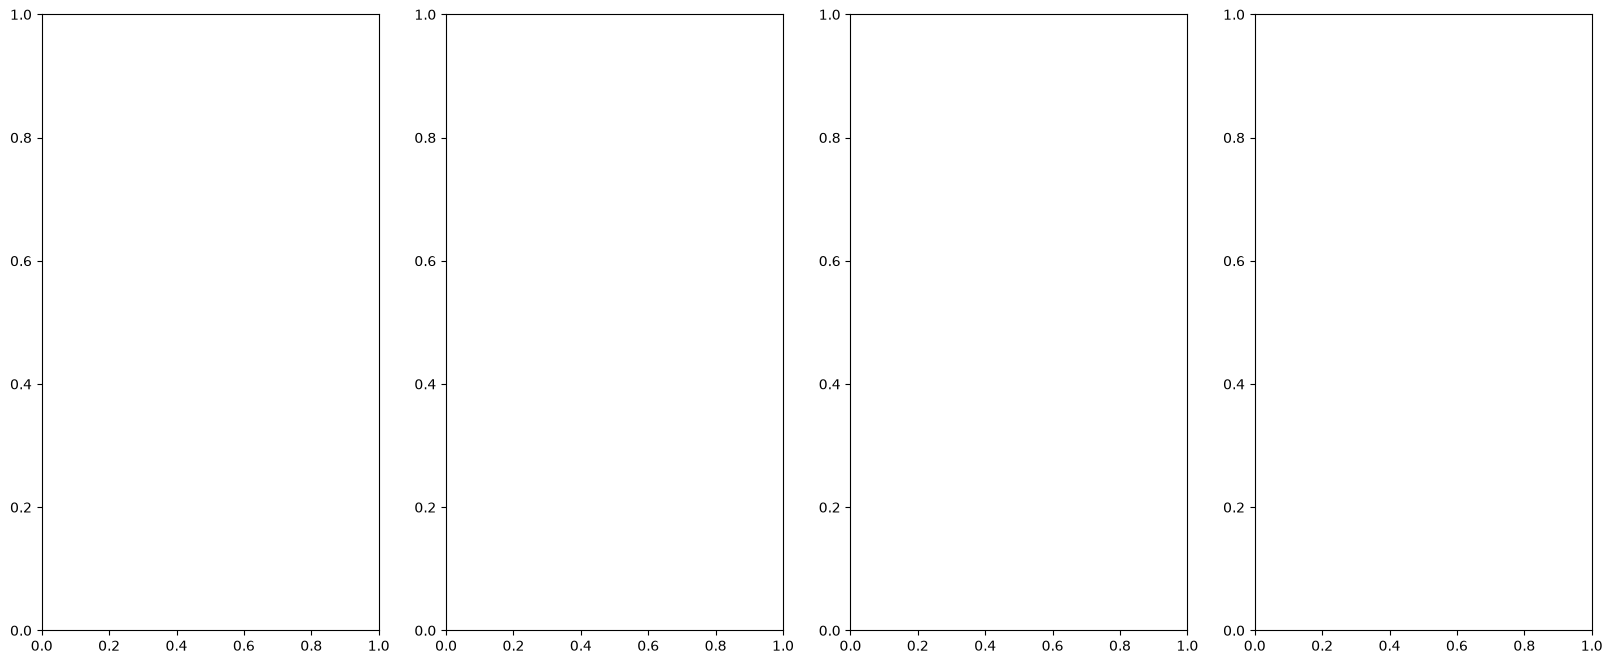

: 

In [ ]:
n_exp     = len(predictions)
mask_cmap = mcolors.ListedColormap(["white", "steelblue", "lightgrey"])

# Layout: first column = false colour, remaining columns = one per experiment
n_cols = n_exp + 1
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 8))

# False colour
axes[0].imshow(fc)
axes[0].set_title("False Colour\n(NIR-R-G)", fontsize=10, fontweight="bold")
axes[0].axis("off")

# Predictions
for col_i, (display_label, exp_name, pred) in enumerate(predictions, start=1):
    pred_display = np.where(pred == 255, 2, pred)
    water_pct    = (pred == 1).sum() / (pred != 255).sum() * 100
    axes[col_i].imshow(pred_display, cmap=mask_cmap, vmin=0, vmax=2,
                       interpolation="nearest")
    axes[col_i].set_title(f"{display_label}\nwater={water_pct:.1f}%",
                           fontsize=10, fontweight="bold")
    axes[col_i].axis("off")

legend_elements = [
    Patch(facecolor="white",     edgecolor="grey", label="Not water"),
    Patch(facecolor="steelblue", edgecolor="grey", label="Water"),
    Patch(facecolor="lightgrey", edgecolor="grey", label="No data"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, 0.01))

plt.suptitle(INPUT_IMAGE.stem, fontsize=13, y=1.01)
plt.tight_layout(rect=[0, 0.05, 1, 1])

if SAVE_PLOT:
    plot_path = OUTPUT_DIR / f"{INPUT_IMAGE.stem}_comparison.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    print(f"Plot saved: {plot_path}")

plt.show()

---
## 7. Per-Experiment Water Fraction Summary

In [ ]:
import pandas as pd

rows = []
for display_label, exp_name, pred in predictions:
    valid      = pred != 255
    water_px   = (pred == 1).sum()
    valid_px   = valid.sum()
    nodata_px  = (pred == 255).sum()
    rows.append({
        "experiment":    display_label,
        "water_px":      int(water_px),
        "valid_px":      int(valid_px),
        "nodata_px":     int(nodata_px),
        "water_pct":     round(water_px / valid_px * 100, 2) if valid_px > 0 else 0,
        "nodata_pct":    round(nodata_px / pred.size * 100, 2),
    })

df = pd.DataFrame(rows).set_index("experiment")
display(df)